In [1]:
%load_ext autoreload
%autoreload 2

In [40]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib
from matplotlib.gridspec import GridSpec
import matplotlib.patches
import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from logger import Logger
from flax import serialization

# from schmitt_tdvp_bridge_jaxmg import TDVPSchmittBridgeJAXMg as DynamicsDriver
from schmitt_tdvp_bridge import TDVPSchmittBridge
from schmitt_tdvp import TDVPSchmitt

from tfim_exact_majorana import run_ed
import numpy as np

In [3]:
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("parity", "Mean"),
    ("parity", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values"),
)


def main(N, n_samples_tvmc, driver_type, q, alpha, load_parameter_path=None, t0=0.0, extra_str=""):
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

    def get_model():
        return nk.models.RBM(
            alpha=alpha,
            param_dtype=complex,
        )

    def get_vstate(n_samples):
        seed = 300
        model = get_model()
        sampler = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples
        )
        vstate = nk.vqs.MCState(
            sampler=sampler,
            model=model,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
        )

        # zero everything
        pars = jax.tree_util.tree_map(lambda x: jnp.zeros_like(x), vstate.parameters)

        W = pars["Dense"]["kernel"]
        a = pars["visible_bias"]
        b = pars["Dense"]["bias"]
        n = hilbert.size
        # b + W x = i pi/4 (1 - sum_i x_i), x_i in \{+1,-1\}
        #   -> even x: b + W x = i(k+1) pi /2 ->  cosh(b + W x)= +-1
        #   -> odd x: b + W x = i k pi /2 -> cosh(b + W x)= 0
        W = W.at[:, 0].set(-1j * (np.pi / 4))
        b = b.at[0].set(1j * (np.pi / 4) * n)
        # Repeat to get rid of sign since now
        # psi(x) =  cosh(b_0 + sum_i W_0i x) * cosh(b_1 + sum_i W_1i x)
        #   -> even x: 1
        #   -> odd x: 0
        W = W.at[:, 1].set(-1j * (np.pi / 4))
        b = b.at[1].set(1j * (np.pi / 4) * n)
        # Unit 3 left as zero (neutral)
        pars["Dense"]["kernel"] = W
        pars["Dense"]["bias"] = (
            b + (1 + 1j) * jax.random.uniform(jax.random.key(100), b.shape) * 1e-4
        )
        pars["visible_bias"] = (
            jnp.zeros_like(pars["visible_bias"])
            + (1 + 1j) * jax.random.uniform(jax.random.key(100), a.shape) * N * 1e-4
        )

        # visible_bias stays zero
        vstate.parameters = pars
        return vstate

    # Check energy and parity
    sigma_z = nk.operator.PauliStringsJax(hilbert, "Z" * N, 1.0)
    graph = nk.graph.Chain(N, pbc=True)
    Hxx = sum([sigmax(hilbert, i) @ sigmax(hilbert, j) for i, j in graph.edges()])
    stab_hamiltonian = -Hxx - sigma_z
    # Hamiltonian
    hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=-1.0, J=1.0)

    def measure_parity(step, log, driver):
        log["parity"] = driver.state.expect(sigma_z)
        return True

    T = 2.0
    save_times = np.linspace(0.0, T, 40)
    if driver_type == "bridge":
        exp_name = f"bridge_{n_samples_tvmc}_{q:1.2f}"
    elif driver_type == "vanilla":
        exp_name = f"vanilla_{n_samples_tvmc}"
    else:
        raise NotImplementedError
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_{N}_parity/RBM_{alpha}/{extra_str}{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
    else:
        dt = 1e-5
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    vstate = get_vstate(n_samples_tvmc)
    if load_parameter_path is not None:
        with open(
            load_parameter_path,
            "rb",
        ) as infile:
            binary_data = infile.read()
            vstate.variables = serialization.from_bytes(vstate.variables, binary_data)
            vstate.variables = jax.tree.map(lambda x: jnp.array(x), vstate.variables)
        T = T - t0

    # Thermalize
    for i in range(1):
        vstate.sample()

    parity_expect = vstate.expect(sigma_z)
    stab_energy = vstate.expect(stab_hamiltonian)
    print(f"parity: {parity_expect}")
    print(f"parity: {stab_energy}")

    # Callbacks
    callbacks = []
    callbacks.append(measure_parity)
    acceptance_rate_callback = get_acceptance_rate_callback()
    callbacks.append(acceptance_rate_callback)
    if driver_type == "bridge":
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    elif driver_type == "vanilla":
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)

    # Set up dynamics
    integrator = RK45(dt, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    tvmc_kwargs = {}

    if driver_type == "bridge":
        dynamics = TDVPSchmittBridge(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            q=q,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    elif driver_type == "vanilla":
        dynamics = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        raise NotImplementedError

    dynamics.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [ ]:
for q in (0.1, 0.3, 0.5, 0.7, 0.9):
    main(8, 2**12, "bridge", q, alpha=4)

# load_path = (
#     f"./data/TFIM_{8}_parity/RBM_{4}/bridge_{2**12}_{0.5:1.2f}/log_params_1.mpack"
# )
# main(8, 2**12, "vanilla", q, alpha=4, load_parameter_path=load_path, t0=0.05, extra_str="hotstart_")
main(8, 2**12, "vanilla", q, alpha=4)

Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...


Restored: True
Restored: True
Restored q:0.10 True


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Restored q:0.30 True
Restored q:0.50 True
Restored q:0.70 True
Restored q:0.90 True


/tmp/ipykernel_1741746/170519835.py:63: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z.plot(
/tmp/ipykernel_1741746/170519835.py:96: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_inset.plot(times_exact, np.real(parity_exact), "k-", linewidth=1, linestyle="dashed")


Restored q:0.10 True
[array(nan), array(0.89844886), array(0.9021112), array(0.89600915), array(0.90308939), array(0.90162633), array(0.8972347), array(0.8962611), array(0.9052956), array(0.89553682), array(0.90408563), array(0.89799364), array(0.89410301), array(0.90461595), array(0.89830681), array(0.90080069), array(0.89965455), array(0.890201), array(0.89363679), array(0.89828887), array(0.90949118), array(0.89855571), array(0.90464655), array(0.89322625), array(0.89493758), array(0.90564614), array(0.9058976), array(0.89739543), array(0.89108435), array(0.90373651), array(0.89791376), array(0.89792504), array(0.90255472), array(0.90159446), array(0.89456), array(0.90647641), array(0.89992639), array(0.89799258), array(0.89605981), array(0.90141269), array(0.9014218), array(0.8982791), array(0.89416521), array(0.90170286), array(0.90098503), array(0.90754812), array(0.90076484), array(0.90150333), array(0.89812114), array(0.90493651), array(0.90252433), array(0.89647944), array(0.8

/tmp/ipykernel_1741746/170519835.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


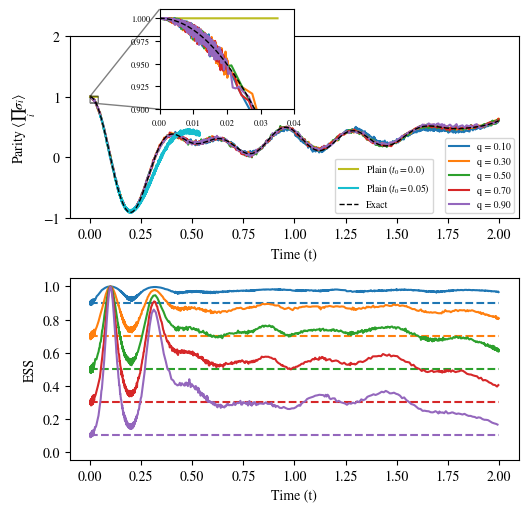

In [66]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
n_samples_list = [2**i for i in range(10, 14)]
N = 8
alpha = 4
n_samples_to_plot = 2**12

times_exact, parity_exact = run_ed(N, h=1.0, J=1.0, T=2.0)
# Create figure with custom GridSpec for bottom row spacing
fig = plt.figure(figsize=(5.8, 5.5))
gs = GridSpec(2, 1, figure=fig, wspace=0.3, hspace=0.33)
ax_z = fig.add_subplot(gs[0, 0])
ax_ess = fig.add_subplot(gs[1, 0])
# ax_snrF_bridge = fig.add_subplot(gs[1, :1])
# ax_snrF_vanilla = fig.add_subplot(gs[1, 1])


# Vanilla Parity started from 0.05
save_path_vanilla = f"./data/TFIM_{N}_parity/RBM_{alpha}/vanilla_{n_samples_to_plot}/"
logger_vanilla = Logger(path=save_path_vanilla, fields=fields_to_track)
print("Restored:", logger_vanilla.restore())
color_t00 = "tab:olive"
color_t005 = "tab:cyan"
ax_z.plot(
    logger_vanilla.data["t"]["values"],
    logger_vanilla.data["parity"]["Mean"],
    label=f"Plain ($t_0=0.0$)",
    zorder=1,
    color=color_t00,
)
# Vanilla Parity started from 0.05
save_path_vanilla_hotstart = f"./data/TFIM_{N}_parity/RBM_{alpha}/hotstart_vanilla_{n_samples_to_plot}/"
logger_vanilla = Logger(path=save_path_vanilla_hotstart, fields=fields_to_track)
print("Restored:", logger_vanilla.restore())
ax_z.plot(
    logger_vanilla.data["t"]["values"][:7000],
    logger_vanilla.data["parity"]["Mean"][:7000],
    label=r"Plain ($t_0=0.05$)",
    zorder=1,
    color=color_t005,
)
ax_z.set_xlabel("Time (t)")
ax_z.set_ylabel(r"Parity $\langle\prod_i \sigma_i\rangle$")

# Bridge Parity
bridge_lines = []
bridge_labels = []
for q in (0.1, 0.3, 0.5, 0.7, 0.9):
    for n_samples in [n_samples_to_plot]:
        exp_name = f"bridge_{n_samples}_{q:1.2f}"
        save_path = (
            f"./data/TFIM_{N}_parity/RBM_{alpha}/bridge_{n_samples_to_plot}_{q:1.2f}/"
        )
        logger = Logger(path=save_path, fields=fields_to_track)
        print(f"Restored q:{q:1.2f}", logger.restore())
        (line,) = ax_z.plot(
            logger.data["t"]["values"],
            logger.data["parity"]["Mean"],
            zorder=0,
        )
        bridge_lines.append(line)
        bridge_labels.append(f"q = {q:1.2f}")
ax_z.plot(
    times_exact,
    np.real(parity_exact),
    "k-",
    linewidth=1,
    label="Exact",
    zorder=1,
    linestyle="dashed",
)

# Inset zoomed in on early time
ax_inset = ax_z.inset_axes([0.2, 0.6, 0.3, 0.55])  # [x, y, width, height] in axes coords
# Re-plot vanilla runs in inset
logger_vanilla_cold = Logger(path=save_path_vanilla, fields=fields_to_track)
logger_vanilla_cold.restore()
ax_inset.plot(
    logger_vanilla_cold.data["t"]["values"],
    logger_vanilla_cold.data["parity"]["Mean"],
    color=color_t00,
)
logger_vanilla_hot = Logger(path=save_path_vanilla_hotstart, fields=fields_to_track)
logger_vanilla_hot.restore()
ax_inset.plot(
    logger_vanilla_hot.data["t"]["values"][:7000],
    logger_vanilla_hot.data["parity"]["Mean"][:7000],
    color=color_t005,
)
# Re-plot bridge runs in inset
for i, q_val in enumerate((0.1, 0.3, 0.5, 0.7, 0.9)):
    sp = f"./data/TFIM_{N}_parity/RBM_{alpha}/bridge_{n_samples_to_plot}_{q_val:1.2f}/"
    lg = Logger(path=sp, fields=fields_to_track)
    lg.restore()
    ax_inset.plot(lg.data["t"]["values"], lg.data["parity"]["Mean"], color=bridge_lines[i].get_color())
ax_inset.plot(times_exact, np.real(parity_exact), "k-", linewidth=1, linestyle="dashed")
ax_inset.set_xlim([0.0, 0.04])
ax_inset.set_ylim([0.9, 1.01])
ax_inset.tick_params(labelsize=6)
ax_z.indicate_inset_zoom(ax_inset, edgecolor="black")
# ESS
for q in (0.1, 0.3, 0.5, 0.7, 0.9):
    for n_samples in [n_samples_to_plot]:
        save_path = f"./data/TFIM_{N}_parity/RBM_{alpha}/bridge_{n_samples}_{q:1.2f}/"
        logger = Logger(path=save_path, fields=fields_to_track)
        print(f"Restored q:{q:1.2f}", logger.restore())
        x_vals = logger.data["t"]["values"]
        ess_vals = logger.data["ess_bridge"]["values"]
        print(ess_vals)
        (line1,) = ax_ess.plot(x_vals, ess_vals, label=f"$q = ${q:1.2f}")
        # Add marker at (0, q)
        ax_ess.hlines(1 - q, 0, 2.0, color=line1.get_color(), linestyle="dashed")

ax_ess.set_xlabel("Time (t)")
ax_ess.set_ylabel("ESS")
ax_ess.set_ylim(-0.05, 1.05)
# Two separate legends, both on the right
handles, labels = ax_z.get_legend_handles_labels()  # Plain x2 + Exact
# First legend: Plain + Exact, positioned to the left of the q legend
leg1 = ax_z.legend(handles, labels, loc="lower right", fontsize=7, bbox_to_anchor=(0.82, 0.0))
ax_z.add_artist(leg1)
# Second legend: bridge q-values at lower right
ax_z.legend(bridge_lines, bridge_labels, loc="lower right", fontsize=7)
ax_z.set_ylim([-1.01,2.])

# # SNR F
# norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
# for i, sp in enumerate([save_path, save_path_vanilla]):
#     if i == 0:
#         ax = ax_snrF_bridge
#     else:
#         ax = ax_snrF_vanilla
#     logger = Logger(path=sp, fields=fields_to_track)
#     logger.restore()
#     # Include max_weight_over_mean if present
#     snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
#     cmap_snrF = plt.get_cmap("viridis")
#     for i in range(snrF_len):
#         snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
#         # print(snr_F_data)
#         frac = 0.0 if snrF_len <= 1 else i / 40
#         ax.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
#     snrF_med_series = logger.data.get("snrF_med", {}).get("values", [])
#     snrF_min_series = logger.data.get("snrF_min", {}).get("values", [])
#     ax.set_xlabel(r"Parameter index $k$")

#     ax.set_yscale("log")
# ax_snrF_bridge.set_ylabel("SNR(F)")
# # Share y-axis between bridge and vanilla plots
# ax_snrF_vanilla.sharey(ax_snrF_bridge)
# # Hide inner y-axis labels
# ax_snrF_vanilla.tick_params(labelleft=False)
# ax_snrF_bridge.tick_params(labelright=False)
# ax_snrF_bridge.set_ylim([1e-2, 1e2])
# # Show outer y-axis labels

# # Add colorbar for ax_snrF_vanilla
# sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
# sm_snrF.set_array([])
# cbar = fig.colorbar(
#     sm_snrF, ax=[ax_snrF_bridge, ax_snrF_vanilla], pad=0.02, label="Time (t)", aspect=20
# )
# plt.savefig("Fig2.pdf")plt.show()

# plt.savefig("Fig2.pdf")plt.show()

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.savefig("Fig2.pdf")